Метод ангиографа

In [138]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import plotly.graph_objects as go
from scipy.ndimage import zoom
import cv2
from torchvision import transforms as T
import torchvision.transforms as T
import numpy as np
import os
import torch
from common import *
from matplotlib import pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import PIL
import PIL.Image
import cv2
from kemsekov_torch.positional_emb import PositionalEncodingPermute
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.ndimage import affine_transform
import random
import skimage.measure
from scipy.ndimage import rotate
from scipy.spatial.transform import Rotation
from scipy.ndimage import gaussian_filter
from torch.cuda.amp import GradScaler, autocast
from typing import List


In [139]:

class GeneratedDataset(torch.utils.data.Dataset):
    def __init__(self, images_dir, labels_dir, info_dir, images_transform=None, projections_order=['a', 'b']):
        super().__init__()
        
        self.projections_order = projections_order
        
        # Считываем разметку
        labels = os.listdir(labels_dir)
        index_to_label = {i.split('.')[0]: os.path.join(labels_dir, i) for i in labels}
        
        # Считываем изображения
        images = os.listdir(images_dir)
        image_labels = [i.split("image")[1].split(".")[0] for i in images]
        
        data = {}
        for image, label in zip(images, image_labels):
            label_index = label[:-1]
            label_letter = label[-1]
            if label_index not in data:
                data[label_index] = {}
            data[label_index][label_letter] = os.path.join(images_dir, image)
        
        # Добавляем метки и проекции
        for i in index_to_label:
            row = data[i]
            row['label'] = index_to_label[i]
            projections = [row[p] for p in projections_order]
            row['projections'] = projections
        
        # Загружаем углы проекций из info файлов
        self.angles = {}
        info_files = os.listdir(info_dir)
        for info_file in info_files:
            if info_file.endswith(".info.0"):  # Фильтруем нужные файлы
                info_path = os.path.join(info_dir, info_file)
                with open(info_path, 'r') as f:
                    info_data = json.load(f)
                case_id = info_file.split('.')[0]  # ID кейса
                self.angles[case_id] = {
                    'theta': info_data.get("theta_array", []),
                    'phi': info_data.get("phi_array", [])
                }
        
        self.data = data
        self.keys = list(self.data.keys())
        self.images_transform = images_transform if images_transform else lambda x: T.ToTensor()(x)
    
    def __len__(self):
        return len(self.keys)
    
    def __getitem__(self, index):
        key = self.keys[index]
        row = self.data[key]
        label = np.load(row['label'])
        images = [PIL.Image.open(v) for v in row['projections']]
        images = torch.concat([self.images_transform(i) for i in images])
        
        # Получаем углы для данного случая
        angles = self.angles.get(key, {'theta': [0] * len(self.projections_order), 'phi': [0] * len(self.projections_order)})
        theta = torch.tensor(angles['theta'], dtype=torch.float32)
        phi = torch.tensor(angles['phi'], dtype=torch.float32)
        
        return images, torch.tensor(label), theta, phi

In [140]:
# Пути к данным
images_dir = "/home/alexus/Desktop/For_Generator/data0/content/vessel_tree_generator/data/test/images/test"
labels_dir = "/home/alexus/Desktop/For_Generator/data0/content/vessel_tree_generator/data/test/labels/test/"
info_dir = "/home/alexus/Desktop/For_Generator/data0/content/vessel_tree_generator/data/test/info/"

# Трансформации для проекций
def mean_channel(x):
    return x.mean(axis=0)[None, :]

def distance_transform(image_mask):
    image_mask = np.asarray(image_mask)[0]
    binary_mask = (image_mask > np.mean(image_mask)).astype(np.uint8)
    distance = cv2.distanceTransform(binary_mask, cv2.DIST_L2, 5)
    return torch.tensor(image_mask + distance[None, :])

images_transform = T.Compose([
    T.ToTensor(),
    T.Lambda(mean_channel),
    T.Resize((128, 128)),
    T.Lambda(distance_transform),
])

# Загрузка данных
d2 = GeneratedDataset(images_dir, labels_dir, info_dir, images_transform=images_transform)


In [141]:
# Фиксированные параметры
IMAGER_PIXEL_SPACING = 0.35  # мм
SID = 1.2  # метры
DISTANCE_SOURCETOISO = 0.75  # метры
DISTANCE_DETECTORTOISO = SID - DISTANCE_SOURCETOISO  # 0.45 метра
RADIUS_OF_IMAGING_SPHERE = SID  # 1.2 метра
IMG_DIM = 128  # Размер изображения после resize

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

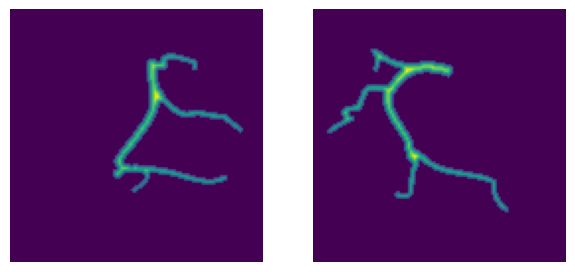

In [142]:
device = 'cuda:0'
sample_index = 6 #random.randint(0,len(d)-1)
sample = d2[sample_index] #d2[1]
plt.figure(figsize=(15,15))
plt.subplot(1,4,1)
plt.imshow(sample[0][0]) #d2[1][0][0]
plt.axis('off')
plt.subplot(1,4,2)
plt.imshow(sample[0][1])
plt.axis('off')

In [143]:
images, label, theta, phi = d2[sample_index]
proj1 = images[0].cpu().numpy() #d2[1][0]
proj2 = images[1].cpu().numpy()
phi1, phi2 =phi[0].item(), phi[1].item()
theta1, theta2 = theta[0].item(), theta[1].item()
proj2.shape

(128, 128)

In [144]:
print(f'angle: theta1={theta1}, phi1={phi1},theta2={theta2}, phi2={phi2} ')

angle: theta1=-130.0, phi1=-100.0,theta2=-19.57345199584961, phi2=-102.37266540527344 


In [221]:
def compute_rotation_matrices(theta, phi, device='cuda:0'):
    theta_rad = torch.deg2rad(torch.tensor(theta, device=device))
    phi_rad = torch.deg2rad(torch.tensor(phi, device=device))
    theta_rad = torch.tensor(theta_rad, dtype=torch.float32, device=device)
    phi_rad = torch.tensor(phi_rad, dtype=torch.float32, device=device)
    AP1 = theta_rad
    AP2 = phi_rad
    AP3 = 0.0
    
    coordSystemChanger = torch.tensor([[0, -1, 0], [1, 0, 0], [0, 0, -1]], dtype=torch.float32, device=device)    
    R_AP1 = coordSystemChanger @ torch.tensor([
        [torch.cos(AP1), -torch.sin(AP1), 0],
        [torch.sin(AP1), torch.cos(AP1), 0],
        [0, 0, 1]
    ],dtype=torch.float32, device=device) @ torch.linalg.inv(coordSystemChanger)
    
    R_AP2 = coordSystemChanger @ torch.tensor([
        [1, 0, 0],
        [0, torch.cos(AP2), torch.sin(AP2)],
        [0, -torch.sin(AP2), torch.cos(AP2)]
    ],dtype=torch.float32, device=device) @ torch.linalg.inv(coordSystemChanger)
    
    R_AP3 = coordSystemChanger @ torch.tensor([
        [torch.cos(AP3), 0, torch.sin(AP3)],
        [0, 1, 0],
        [-torch.sin(AP3), 0, torch.cos(AP3)]
    ], dtype=torch.float32, device=device) @ torch.linalg.inv(coordSystemChanger)
    
    R_total = R_AP1 @ R_AP2 @ R_AP3
    
    localX = R_total @ torch.tensor([0, 1, 0], device=device)
    localY = R_total @ torch.tensor([-1, 0, 0], device=device)
    
    return localX, localY 
# Исправленная функция для вычисления позиций сенсора и источника
def compute_sensor_source(theta, phi, device='cuda:0'):
    theta_rad = torch.deg2rad(torch.tensor(theta, device=device))
    phi_rad = torch.deg2rad(torch.tensor(phi, device=device))
    theta_rad = torch.tensor(theta_rad, dtype=torch.float32, device=device)
    phi_rad = torch.tensor(phi_rad, dtype=torch.float32, device=device)
    dx = torch.sin(phi_rad) * torch.cos(theta_rad)
    dy = torch.sin(phi_rad) * torch.sin(theta_rad)
    dz = -torch.cos(phi_rad)
    direction = torch.tensor([dx, dy, dz], device=device)
    
    coordSystemChanger = torch.tensor([[0, -1, 0], [1, 0, 0], [0, 0, -1]], dtype=torch.float32, device=device)
    direction_transformed = coordSystemChanger @ direction
    
    sensor_pos = direction_transformed * SID  # SID — расстояние до сенсора
    source_pos = -direction_transformed * DISTANCE_SOURCETOISO  # расстояние до источника
    
    localX, localY = compute_rotation_matrices(theta, phi, device)
    
    return sensor_pos, source_pos, localX, localY
# Исправленная функция для создания теней
#@torch.compile
def create_shadow1(projection, phi, theta, volume_shape=(128, 128, 128), device='cuda:0'):
    D_x, D_y, D_z = volume_shape
    projection = projection.to(device=device)
    h, w = projection.shape
    vol = torch.zeros(volume_shape, device=device)
    
    y_coords, x_coords = torch.where(projection > 0)
    intensities = projection[y_coords, x_coords]
    
    sensor_pos, source_pos, localX, localY = compute_sensor_source(theta, -phi, device)
    sensor_width = IMAGER_PIXEL_SPACING * h / 1000  # в метрах
    x_norm = (x_coords - w / 2) / w * sensor_width
    y_norm = (y_coords - h / 2) / h * sensor_width
    
    points_3d = sensor_pos + x_norm[:, None] * localX + y_norm[:, None] * localY
    direction = (source_pos - sensor_pos) / torch.norm(source_pos - sensor_pos)
    
    t = torch.linspace(0, 2 * DISTANCE_SOURCETOISO, D_z, device=device)
    shadow_x = (points_3d[:, 0, None] + direction[0] * t).clamp(-0.6, 0.6)
    shadow_y = (points_3d[:, 1, None] + direction[1] * t).clamp(-0.6, 0.6)
    shadow_z = (points_3d[:, 2, None] + direction[2] * t).clamp(-0.6, 0.6)
    
    # Масштабирование в воксели
    shadow_x = (shadow_x / 1.2 * 100 + 64).long().clamp(0, 127)
    shadow_y = (shadow_y / 1.2 * 100 + 64).long().clamp(0, 127)
    shadow_z = (shadow_z / 1.2 * 100 + 64).long().clamp(0, 127)
    
    for j in range(D_z):
        vol[shadow_y[:, j], shadow_x[:, j], shadow_z[:, j]] = intensities
    return vol
# Остальные функции оставляем без изменений
def create_output_model(output_3d_model: torch.Tensor, volume_shape: List[int]):
    output_3d_model = output_3d_model.clone()
    # Центрируем координаты, как в исходном коде
    mean_coords = output_3d_model[..., :3].mean(dim=(0, 1))
    output_3d_model[..., :3] -= mean_coords
    # Масштабируем для соответствия объёму
    scale = float(output_3d_model[..., :3].max() - output_3d_model[..., :3].min())
    output_3d_model[..., :3] /= scale if scale != 0.0 else 1.0
    output_3d_model[..., -1] /= scale if scale != 0.0 else 1.0
    # Отображаем на индексы объёма (0 до 127)
    output_3d_model[..., :3] = (output_3d_model[..., :3] * 100 + 64).int().clip(0, 127)  # Центр в 64

    T = torch.zeros(volume_shape, dtype=torch.float32)

    for group in range(output_3d_model.shape[0]):
        x = output_3d_model[group, :, 0].long()  # Преобразуем в long
        y = output_3d_model[group, :, 1].long()
        z = output_3d_model[group, :, 2].long()
        R = output_3d_model[group, :, 3] * 10
        for i in range(len(x)):
            radius = int((R[i] * 12).clamp(1, 10))
            x_grid, y_grid, z_grid = torch.meshgrid(
                torch.arange(-radius, radius + 1, dtype=torch.long),
                torch.arange(-radius, radius + 1, dtype=torch.long),
                torch.arange(-radius, radius + 1, dtype=torch.long)
            )
            mask = (x_grid ** 2 + y_grid ** 2 + z_grid ** 2 <= radius ** 2)
            # Гарантируем, что результат операций остаётся в типе long
            x_shifted = (x[i] + x_grid[mask]).long()
            y_shifted = (y[i] + y_grid[mask]).long()
            z_shifted = (z[i] + z_grid[mask]).long()
            
            # Проверяем, что координаты находятся в пределах объёма
            valid = (x_shifted >= 0) & (x_shifted < 128) & (y_shifted >= 0) & (y_shifted < 128) & (z_shifted >= 0) & (z_shifted < 128)
            x_valid = x_shifted[valid]
            y_valid = y_shifted[valid]
            z_valid = z_shifted[valid]

            # Индексация тензора T
            insertion_index = T[x_valid, y_valid, z_valid] == 0
            average_index = T[x_valid, y_valid, z_valid] != 0

            T[x_valid, y_valid, z_valid] += R[i] * insertion_index
            avg = (R[i] + T[x_valid, y_valid, z_valid]) / 2
            T[x_valid, y_valid, z_valid] += (avg - T[x_valid, y_valid, z_valid]) * average_index

    return T

In [222]:
# Визуализация (без изменений)
# Визуализация
def visualize_3d_volumes(shadow1, shadow2, T_trace, title="3D Shadows Reconstruction", sample_points=10000, threshold_factor=0.1):
    traces = []
    
    def get_volume_points(volume, color, name, threshold_factor=threshold_factor):
        volume_max = volume.max()
        if volume_max > 0:
            threshold = threshold_factor * volume_max
        else:
            threshold = 0.01
        nonzero_indices = (volume > threshold).nonzero(as_tuple=False)
        
        if len(nonzero_indices) > 0:
            if len(nonzero_indices) > sample_points:
                indices = torch.randperm(len(nonzero_indices))[:sample_points]
                nonzero_indices = nonzero_indices[indices]
            x_coords = nonzero_indices[:, 0].tolist()
            y_coords = nonzero_indices[:, 1].tolist()
            z_coords = nonzero_indices[:, 2].tolist()
            return go.Scatter3d(
                x=x_coords, y=y_coords, z=z_coords, mode='markers',
                marker=dict(size=3, color=color, opacity=0.8),
                name=name
            )
        return None
    
    shadow1_trace = get_volume_points(shadow1, 'blue', 'Shadow 1', threshold_factor)
    if shadow1_trace:
        traces.append(shadow1_trace)
    else:
        print("No significant nonzero values in shadow1 to visualize! Max value:", shadow1.max().item())
    
    shadow2_trace = get_volume_points(shadow2, 'green', 'Shadow 2', threshold_factor)
    if shadow2_trace:
        traces.append(shadow2_trace)
    else:
        print("No significant nonzero values in shadow2 to visualize! Max value:", shadow2.max().item())
    
    T_trace = get_volume_points(T, 'red', 'T', threshold_factor)
    if T_trace:
        traces.append(T_trace)
    else:
        print("No significant nonzero values in T to visualize! Max value:", T.max().item())
    
    if not traces:
        print("No significant nonzero values (> threshold) to visualize!")
        return
    
    fig = go.Figure(data=traces)
    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title="X", yaxis_title="Y", zaxis_title="Z",
            aspectmode='cube'
        ),
        width=800, height=800,
        template="plotly_dark",
        legend=dict(title="Objects")
    )
    fig.show()

def project_3d_to_2d(volume, phi, theta, volume_shape=(128, 128, 128), device='cuda:0'):
    D_x, D_y, D_z = volume_shape
    projection = torch.zeros((D_x, D_y), dtype=torch.float32, device=device)
    
    sensor_pos, source_pos, localX, localY = compute_sensor_source(theta, -phi, device=device)
    #direction = (source_pos - sensor_pos) / torch.norm(source_pos - sensor_pos)
    direction = (sensor_pos - source_pos) / torch.norm(sensor_pos - source_pos)
    dx, dy, dz = direction[0].item(), direction[1].item(), -direction[2].item()
    
    x = torch.arange(D_x, dtype=torch.float32, device=device)
    y = torch.arange(D_y, dtype=torch.float32, device=device)
    z = torch.arange(D_z, dtype=torch.float32, device=device)
    x, y, z = torch.meshgrid(x, y, z, indexing='ij')
    y = D_y - 1 - y  # Инверсия оси Y
    
    proj_x = (x + dx * z).round().clamp(0, D_x - 1).long()
    proj_y = (y + dy * z).round().clamp(0, D_y - 1).long()
    
    for i in range(D_z):
        mask = volume[:, :, i] > 0
        if mask.any():
            projection[proj_y[mask, i], proj_x[mask, i]] += volume[:, :, i][mask]
    return projection

In [223]:
shadow1_input = sample[0][0].to(dtype=torch.float32, device=device)
shadow2_input = sample[0][1].to(dtype=torch.float32, device=device)
model_input = sample[1].to(dtype=torch.float32, device=device)
shadow1 = create_shadow1(shadow1_input, phi1, theta1, device=device)
shadow2 = create_shadow1(shadow2_input, phi2, theta2, device=device)

/tmp/ipykernel_4303/3681348671.py:39: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).

/tmp/ipykernel_4303/3681348671.py:40: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).

/tmp/ipykernel_4303/3681348671.py:4: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).

/tmp/ipykernel_4303/3681348671.py:5: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).



TypeError: cos(): argument 'input' (position 1) must be Tensor, not float

In [193]:
backprojection = torch.stack([shadow1, shadow2])

# T = create_output_model(model_input, volume_shape=[128, 128, 128], device=device)
T = create_output_model(sample[1], volume_shape = [128,128,128])
print(shadow1.max(), shadow2.max()) 
print(T.sum()) 


tensor(4., device='cuda:0') tensor(4., device='cuda:0')
tensor(378.9905)


In [195]:
visualize_3d_volumes(shadow1, shadow2, T,  
                     title=f"Shadows (theta1={theta1:.1f}, phi1={phi1:.1f}, theta2={theta2:.1f}, phi2={phi2:.1f})")

# Проверка проекций
proj1_3d = project_3d_to_2d(T, phi1, theta1, device=device)
proj2_3d = project_3d_to_2d(T, phi2, theta2, device=device)

proj1_3d = proj1_3d.cpu()
proj2_3d = proj2_3d.cpu()

plt.figure(figsize=(10, 5))
plt.subplot(2, 2, 1)
plt.imshow(sample[0][0].cpu().numpy())
plt.title("Исходная Тень 1")
plt.axis('off')
plt.subplot(2, 2, 2)
plt.imshow(proj1_3d.numpy())
plt.title("Спроецированная 3D-модель (Тень 1)")
plt.axis('off')
plt.subplot(2, 2, 3)
plt.imshow(sample[0][1].cpu().numpy())
plt.title("Исходная Тень 2")
plt.axis('off')
plt.subplot(2, 2, 4)
plt.imshow(proj2_3d.numpy())
plt.title("Спроецированная 3D-модель (Тень 2)")
plt.axis('off')
plt.show()

RuntimeError: "addmv_impl_cuda" not implemented for 'Long'

In [127]:

# Вычисление параметров для двух проекций
theta_array = [theta1, theta2]
phi_array = [phi1, phi2]


shadow1_input = sample[0][0].to(dtype=torch.float32, device=device)
shadow2_input = sample[0][1].to(dtype=torch.float32, device=device)
model_input = sample[1].to(dtype=torch.float32, device=device)

shadow1 = create_shadow1(shadow1_input, phi1, theta1, device=device)
shadow2 = create_shadow1(shadow2_input, phi2, theta2, device=device)
backprojection = torch.stack([shadow1, shadow2])

T = create_output_model(model_input, volume_shape=[128, 128, 128], device=device)

# Попробуем дополнительный поворот для theta1 (например, +180)
theta1_rotated = theta1
proj1_3d = project_3d_to_2d(T, phi1, theta1_rotated, device=device)
proj2_3d = project_3d_to_2d(T, phi2, theta2, device=device)

proj1_3d = proj1_3d.cpu()
proj2_3d = proj2_3d.cpu()

plt.figure(figsize=(10, 5))
plt.subplot(2, 2, 1)
plt.imshow(sample[0][0].cpu().numpy())
plt.title("Исходная Тень 1")
plt.axis('off')
plt.subplot(2, 2, 2)
plt.imshow(proj1_3d.numpy())
plt.title("Спроецированная 3D-модель (Тень 1, theta+180)")
plt.axis('off')
plt.subplot(2, 2, 3)
plt.imshow(sample[0][1].cpu().numpy())
plt.title("Исходная Тень 2")
plt.axis('off')
plt.subplot(2, 2, 4)
plt.imshow(proj2_3d.numpy())
plt.title("Спроецированная 3D-модель (Тень 2)")
plt.axis('off')
plt.show()


theta: -130.0, type: <class 'float'>
phi: -100.0, type: <class 'float'>
Sensor position: tensor([-0.9053,  0.7596, -0.2084], device='cuda:0')
Source position: tensor([ 0.5658, -0.4748,  0.1302], device='cuda:0')
localX: tensor([ 0.0000, -0.2645, -0.9644], device='cuda:0'), localY: tensor([-0.6564, -0.7275,  0.1996], device='cuda:0')


TypeError: linspace() received an invalid combination of arguments - got (int, float, float, device=str), but expected one of:
 * (Tensor start, Tensor end, int steps, *, Tensor out = None, torch.dtype dtype = None, torch.layout layout = None, torch.device device = None, bool pin_memory = False, bool requires_grad = False)
 * (Number start, Tensor end, int steps, *, Tensor out = None, torch.dtype dtype = None, torch.layout layout = None, torch.device device = None, bool pin_memory = False, bool requires_grad = False)
 * (Tensor start, Number end, int steps, *, Tensor out = None, torch.dtype dtype = None, torch.layout layout = None, torch.device device = None, bool pin_memory = False, bool requires_grad = False)
 * (Number start, Number end, int steps, *, Tensor out = None, torch.dtype dtype = None, torch.layout layout = None, torch.device device = None, bool pin_memory = False, bool requires_grad = False)


In [161]:


def visualize_3d_volumes(shadow1, shadow2, T_trace, title="3D Shadows Reconstruction", sample_points=10000, threshold_factor=0.1):
    # Список для хранения данных трасс (traces)
    traces = []
    
    # Функция для извлечения координат из объёма с фильтрацией по интенсивности
    def get_volume_points(volume, color, name, threshold_factor=threshold_factor):
        # Адаптивный порог: берём threshold_factor * максимальное значение
        volume_max = volume.max()
        if volume_max > 0:
            threshold = threshold_factor * volume_max  # Порог, например, 10% от максимума
        else:
            threshold = 0.01  # Минимальный порог
        nonzero_indices = (volume > threshold).nonzero(as_tuple=False)
        
        if len(nonzero_indices) > 0:
            if len(nonzero_indices) > sample_points:
                indices = torch.randperm(len(nonzero_indices))[:sample_points]
                nonzero_indices = nonzero_indices[indices]
            x_coords = nonzero_indices[:, 0].tolist()
            y_coords = nonzero_indices[:, 1].tolist()
            z_coords = nonzero_indices[:, 2].tolist()
            return go.Scatter3d(
                x=x_coords, y=y_coords, z=z_coords, mode='markers',
                marker=dict(size=3, color=color, opacity=0.8),  # Фиксированный цвет
                name=name
            )
        return None
    
    # Добавляем shadow1 (красный цвет)
    shadow1_trace = get_volume_points(shadow1, 'blue', 'Shadow 1', threshold_factor)
    if shadow1_trace:
        traces.append(shadow1_trace)
    else:
        print("No significant nonzero values in shadow1 to visualize! Max value:", shadow1.max().item())
    
    # Добавляем shadow2 (синий цвет)
    shadow2_trace = get_volume_points(shadow2, 'green', 'Shadow 2', threshold_factor)
    if shadow2_trace:
        traces.append(shadow2_trace)
    else:
        print("No significant nonzero values in shadow2 to visualize! Max value:", shadow2.max().item())
    T_trace = get_volume_points(T, 'red', 'T', threshold_factor)
    if T_trace:
        traces.append(T_trace)
    else:
        print("No significant nonzero values in shadow2 to visualize! Max value:", T_trace.max().item())
    # Если нет данных для отображения
    if not traces:
        print("No significant nonzero values (> threshold) to visualize!")
        return
    
    # Создаём график
    fig = go.Figure(data=traces)
    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title="X", yaxis_title="Y", zaxis_title="Z",
            aspectmode='cube'
        ),
        width=800, height=800,
        template="plotly_dark",
        legend=dict(title="Objects")
    )
    fig.show()

# Пример использования
theta1, phi1 = sample[2][0].item(), sample[3][0].item()
theta2, phi2 = sample[2][1].item(), sample[3][1].item()
visualize_3d_volumes(backprojection[0], backprojection[1], T,  
                     title=f"Shadows (theta1={theta1:.1f}, phi1={phi1:.1f}, theta2={theta2:.1f}, phi2={phi2:.1f})")

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import plotly.graph_objects as go
from scipy.ndimage import zoom, gaussian_filter
import cv2
from torchvision import transforms as T
import numpy as np
import os
from matplotlib import pyplot as plt
import plotly.io as pio

# Пути к данным
images_dir = "/home/alexus/Desktop/For_Generator/data0/content/vessel_tree_generator/data/test/images/test"
labels_dir = "/home/alexus/Desktop/For_Generator/data0/content/vessel_tree_generator/data/test/labels/test/"
info_dir = "/home/alexus/Desktop/For_Generator/data0/content/vessel_tree_generator/data/test/info/"

# Трансформации для проекций
def mean_channel(x):
    return x.mean(axis=0)[None, :]

def distance_transform(image_mask):
    image_mask = np.asarray(image_mask)[0]
    binary_mask = (image_mask > np.mean(image_mask)).astype(np.uint8)
    distance = cv2.distanceTransform(binary_mask, cv2.DIST_L2, 5)
    return torch.tensor(image_mask + distance[None, :])

images_transform = T.Compose([
    T.ToTensor(),
    T.Lambda(mean_channel),
    T.Resize((128, 128)),
    T.Lambda(distance_transform),
])

# Загрузка данных
d2 = GeneratedDataset(images_dir, labels_dir, info_dir, images_transform=images_transform)

sample_index = 3
sample = d2[sample_index]
images, label, theta, phi = d2[sample_index]
proj1 = images[0].cpu().numpy()
proj2 = images[1].cpu().numpy()
phi1, phi2 = phi[0].item(), phi[1].item()
theta1, theta2 = theta[0].item(), theta[1].item()

# Фиксированные параметры
IMAGER_PIXEL_SPACING = 0.35  # мм
SID = 1.2  # метры
DISTANCE_SOURCETOISO = 0.75  # метры
DISTANCE_DETECTORTOISO = SID - DISTANCE_SOURCETOISO  # 0.45 метра
RADIUS_OF_IMAGING_SPHERE = SID  # 1.2 метра

# Функция для вычисления позиций сенсора и источника
def compute_sensor_source(theta, phi, device='cuda:0'):
    if isinstance(theta, torch.Tensor):
        theta = theta.item()
    if isinstance(phi, torch.Tensor):
        phi = phi.item()
    
    phi = -(phi) + 90
    theta_rad = torch.deg2rad(torch.tensor(theta, dtype=torch.float32, device=device))
    phi_rad = torch.deg2rad(torch.tensor(phi, dtype=torch.float32, device=device))
    
    coordSystemChanger = torch.tensor([[0, -1, 0], [1, 0, 0], [0, 0, -1]], dtype=torch.float32, device=device)
    inv_coordSystemChanger = torch.inverse(coordSystemChanger)
    
    Rotation_AP1 = coordSystemChanger @ torch.tensor([
        [torch.cos(theta_rad), -torch.sin(theta_rad), 0],
        [torch.sin(theta_rad), torch.cos(theta_rad), 0],
        [0, 0, 1]
    ], dtype=torch.float32, device=device) @ inv_coordSystemChanger

    Rotation_AP1[:, :, jj] = coordSystemChanger @ np.array(
        [[np.cos(AP1), -np.sin(AP1), 0], [np.sin(AP1), np.cos(AP1), 0], [0, 0, 1]]) @ np.linalg.inv(
        coordSystemChanger)
    
    Rotation_AP2 = coordSystemChanger @ torch.tensor([
        [1, 0, 0],
        [0, torch.cos(phi_rad), torch.sin(phi_rad)],
        [0, -torch.sin(phi_rad), torch.cos(phi_rad)]
    ], dtype=torch.float32, device=device) @ inv_coordSystemChanger
    
    Rotation_AP3 = coordSystemChanger @ torch.tensor([
        [1, 0, 0],
        [0, 1, 0],
        [0, 0, 1]
    ], dtype=torch.float32, device=device) @ inv_coordSystemChanger
    
    rotation = Rotation_AP1 @ Rotation_AP2 @ Rotation_AP3
    
    sensor_pos = (rotation @ torch.tensor([[0], [0], [1]], dtype=torch.float32, device=device) * RADIUS_OF_IMAGING_SPHERE).squeeze()
    source_pos = -sensor_pos / RADIUS_OF_IMAGING_SPHERE * DISTANCE_SOURCETOISO
    localX = (rotation @ torch.tensor([[0], [1], [0]], dtype=torch.float32, device=device)).squeeze()
    localY = (rotation @ torch.tensor([[-1], [0], [0]], dtype=torch.float32, device=device)).squeeze()
    
    localX = localX / torch.norm(localX)
    localY = localY / torch.norm(localY)
    
    print(f"Sensor position: {sensor_pos}")
    print(f"Source position: {source_pos}")
    print(f"localX: {localX}, localY: {localY}")
    
    return sensor_pos, source_pos, localX, localY

# Функция для создания теней
def create_shadow1(projection, phi, theta, volume_shape=(128, 128, 128), device='cuda:0'):
    D_x, D_y, D_z = volume_shape
    projection = projection.clone().to(dtype=torch.float32, device=device)
    h, w = projection.shape
    vol = torch.zeros(volume_shape, dtype=torch.float32, device=device)
    
    y_coords, x_coords = torch.where(projection > 0)
    intensities = projection[y_coords, x_coords]
    
    intensities = intensities / (intensities.max() + 1e-6)
    radii = (intensities * 10).clamp(2, 10)
    
    sensor_pos, source_pos, localX, localY = compute_sensor_source(theta, phi, device=device)
    
    sensor_width = IMAGER_PIXEL_SPACING * h / 1000
    x_norm = (x_coords - w / 2) / w * sensor_width
    y_norm = (y_coords - h / 2) / h * sensor_width
    
    points_3d = sensor_pos + x_norm[:, None] * localX + y_norm[:, None] * localY
    
    direction = (sensor_pos - source_pos) / torch.norm(sensor_pos - source_pos)
    dx, dy, dz = direction[0], direction[1], direction[2]
    
    t = torch.linspace(0, 2 * DISTANCE_SOURCETOISO, D_z * 4, device=device)
    shadow_x = source_pos[0] + dx * t[None, :] + x_norm[:, None] * localX[0] + y_norm[:, None] * localY[0]
    shadow_y = source_pos[1] + dy * t[None, :] + x_norm[:, None] * localX[1] + y_norm[:, None] * localY[1]
    shadow_z = source_pos[2] + dz * t[None, :] + x_norm[:, None] * localX[2] + y_norm[:, None] * localY[2]
    
    shadow_x = ((shadow_x + DISTANCE_SOURCETOISO) / (2 * DISTANCE_SOURCETOISO) * D_x).clamp(0, D_x - 1)
    shadow_y = ((shadow_y + DISTANCE_SOURCETOISO) / (2 * DISTANCE_SOURCETOISO) * D_y).clamp(0, D_y - 1)
    shadow_z = ((shadow_z + DISTANCE_SOURCETOISO) / (2 * DISTANCE_SOURCETOISO) * D_z).clamp(0, D_z - 1)
    
    for j in range(len(t)):
        for i in range(len(x_coords)):
            radius = int(radii[i].item())
            for r_x in range(-radius, radius + 1):
                for r_y in range(-radius, radius + 1):
                    for r_z in range(-radius, radius + 1):
                        if r_x**2 + r_y**2 + r_z**2 <= radius**2:
                            x_idx = (shadow_x[i, j] + r_x).clamp(0, D_x - 1).long()
                            y_idx = (shadow_y[i, j] + r_y).clamp(0, D_y - 1).long()
                            z_idx = (shadow_z[i, j] + r_z).clamp(0, D_z - 1).long()
                            insertion_index = vol[y_idx, x_idx, z_idx] == 0
                            average_index = vol[y_idx, x_idx, z_idx] != 0
                            vol[y_idx, x_idx, z_idx] += intensities[i] * insertion_index
                            avg = (intensities[i] + vol[y_idx, x_idx, z_idx]) / 2
                            vol[y_idx, x_idx, z_idx] += (avg - vol[y_idx, x_idx, z_idx]) * average_index
    
    vol_np = vol.cpu().numpy()
    vol_np = gaussian_filter(vol_np, sigma=1)
    vol = torch.tensor(vol_np, dtype=torch.float32, device=device)
    
    return vol / (vol.max() + 1e-6)

# Функция для создания модели
def create_output_model(output_3d_model: torch.Tensor, volume_shape: list, device='cuda:0'):
    output_3d_model = output_3d_model.clone().to(dtype=torch.float32, device=device)
    mean_coords = output_3d_model[..., :3].mean(dim=(0, 1))
    output_3d_model[..., :3] -= mean_coords
    scale = float(output_3d_model[..., :3].max() - output_3d_model[..., :3].min())
    output_3d_model[..., :3] /= scale if scale != 0.0 else 1.0
    output_3d_model[..., -1] /= scale if scale != 0.0 else 1.0
    output_3d_model[..., :3] = (output_3d_model[..., :3] * 100 + 64).int().clip(0, 127)

    T = torch.zeros(volume_shape, dtype=torch.float32, device=device)

    for group in range(output_3d_model.shape[0]):
        x = output_3d_model[group, :, 0].long()
        y = output_3d_model[group, :, 1].long()
        z = output_3d_model[group, :, 2].long()
        R = output_3d_model[group, :, 3] * 10
        for i in range(len(x)):
            radius = int((R[i] * 12).clamp(1, 10).item())
            x_grid, y_grid, z_grid = torch.meshgrid(
                torch.arange(-radius, radius + 1, dtype=torch.long, device=device),
                torch.arange(-radius, radius + 1, dtype=torch.long, device=device),
                torch.arange(-radius, radius + 1, dtype=torch.long, device=device)
            )
            mask = (x_grid ** 2 + y_grid ** 2 + z_grid ** 2 <= radius ** 2)
            x_shifted = (x[i] + x_grid[mask]).long()
            y_shifted = (y[i] + y_grid[mask]).long()
            z_shifted = (z[i] + z_grid[mask]).long()
            
            valid = (x_shifted >= 0) & (x_shifted < 128) & (y_shifted >= 0) & (y_shifted < 128) & (z_shifted >= 0) & (z_shifted < 128)
            x_valid = x_shifted[valid]
            y_valid = y_shifted[valid]
            z_valid = z_shifted[valid]

            insertion_index = T[x_valid, y_valid, z_valid] == 0
            average_index = T[x_valid, y_valid, z_valid] != 0

            T[x_valid, y_valid, z_valid] += R[i] * insertion_index
            avg = (R[i] + T[x_valid, y_valid, z_valid]) / 2
            T[x_valid, y_valid, z_valid] += (avg - T[x_valid, y_valid, z_valid]) * average_index

    return T

# Функция для проецирования 3D в 2D
def project_3d_to_2d(volume, phi, theta, volume_shape=(128, 128, 128), device='cuda:0'):
    D_x, D_y, D_z = volume_shape
    projection = torch.zeros((D_x, D_y), dtype=torch.float32, device=device)
    
    sensor_pos, source_pos, localX, localY = compute_sensor_source(theta, phi, device=device)
    direction = (source_pos - sensor_pos) / torch.norm(source_pos - sensor_pos)
    dx, dy, dz = direction[0].item(), direction[1].item(), -direction[2].item()
    
    x = torch.arange(D_x, dtype=torch.float32, device=device)
    y = torch.arange(D_y, dtype=torch.float32, device=device)
    z = torch.arange(D_z, dtype=torch.float32, device=device)
    x, y, z = torch.meshgrid(x, y, z, indexing='ij')
    y = D_y - 1 - y
    
    proj_x = (x + dx * z).round().clamp(0, D_x - 1).long()
    proj_y = (y + dy * z).round().clamp(0, D_y - 1).long()
    
    for i in range(D_z):
        mask = volume[:, :, i] > 0
        if mask.any():
            projection[proj_y[mask, i], proj_x[mask, i]] += volume[:, :, i][mask]
    return projection

# Создание теней и модели
device = 'cuda:0'
shadow1_input = sample[0][0].to(dtype=torch.float32, device=device)
shadow2_input = sample[0][1].to(dtype=torch.float32, device=device)
model_input = sample[1].to(dtype=torch.float32, device=device)

shadow1 = create_shadow1(shadow1_input, phi1, theta1, device=device)
shadow2 = create_shadow1(shadow2_input, phi2, theta2, device=device)
backprojection = torch.stack([shadow1, shadow2])

T = create_output_model(model_input, volume_shape=[128, 128, 128], device=device)

# Вычисляем позиции сенсора и источника для каждого угла
for i in range(len(theta)):
    sensor_pos, source_pos, localX, localY = compute_sensor_source(theta[i].item(), phi[i].item(), device=device)
    print(f"Projection {i+1}:")
    print(f"Sensor position: {sensor_pos}")
    print(f"Source position: {source_pos}")
    print(f"localX: {localX}, localY: {localY}")

print(shadow1.max(), shadow2.max())
print(T.sum())

# Визуализация
def visualize_3d_volumes(shadow1, shadow2, T_trace, title="3D Shadows Reconstruction", sample_points=10000, threshold_factor=0.05):
    traces = []
    
    def get_volume_points(volume, color, name, threshold_factor=threshold_factor):
        volume_max = volume.max()
        if volume_max > 0:
            threshold = threshold_factor * volume_max
        else:
            threshold = 0.01
        nonzero_indices = (volume > threshold).nonzero(as_tuple=False)
        
        if len(nonzero_indices) > 0:
            if len(nonzero_indices) > sample_points:
                indices = torch.randperm(len(nonzero_indices))[:sample_points]
                nonzero_indices = nonzero_indices[indices]
            x_coords = nonzero_indices[:, 0].tolist()
            y_coords = nonzero_indices[:, 1].tolist()
            z_coords = nonzero_indices[:, 2].tolist()
            return go.Scatter3d(
                x=x_coords, y=y_coords, z=z_coords, mode='markers',
                marker=dict(size=3, color=color, opacity=0.8),
                name=name
            )
        return None
    
    shadow1_trace = get_volume_points(shadow1, 'blue', 'Shadow 1', threshold_factor)
    if shadow1_trace:
        traces.append(shadow1_trace)
    else:
        print("No significant nonzero values in shadow1 to visualize! Max value:", shadow1.max().item())
    
    shadow2_trace = get_volume_points(shadow2, 'green', 'Shadow 2', threshold_factor)
    if shadow2_trace:
        traces.append(shadow2_trace)
    else:
        print("No significant nonzero values in shadow2 to visualize! Max value:", shadow2.max().item())
    
    T_trace = get_volume_points(T, 'red', 'T', threshold_factor)
    if T_trace:
        traces.append(T_trace)
    else:
        print("No significant nonzero values in T to visualize! Max value:", T.max().item())
    
    if not traces:
        print("No significant nonzero values (> threshold) to visualize!")
        return
    
    fig = go.Figure(data=traces)
    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title="X", yaxis_title="Y", zaxis_title="Z",
            aspectmode='cube'
        ),
        width=800, height=800,
        template="plotly_dark",
        legend=dict(title="Objects")
    )
    fig.show()

visualize_3d_volumes(shadow1, shadow2, T,  
                     title=f"Shadows (theta1={theta1:.1f}, phi1={phi1:.1f}, theta2={theta2:.1f}, phi2={phi2:.1f})",
                     threshold_factor=0.05)

# Проверка проекций
proj1_3d = project_3d_to_2d(T, phi1, theta1, device=device)
proj2_3d = project_3d_to_2d(T, phi2, theta2, device=device)

proj1_3d = proj1_3d.cpu()
proj2_3d = proj2_3d.cpu()

plt.figure(figsize=(10, 5))
plt.subplot(2, 2, 1)
plt.imshow(sample[0][0].cpu().numpy())
plt.title("Исходная Тень 1")
plt.axis('off')
plt.subplot(2, 2, 2)
plt.imshow(proj1_3d.numpy())
plt.title("Спроецированная 3D-модель (Тень 1)")
plt.axis('off')
plt.subplot(2, 2, 3)
plt.imshow(sample[0][1].cpu().numpy())
plt.title("Исходная Тень 2")
plt.axis('off')
plt.subplot(2, 2, 4)
plt.imshow(proj2_3d.numpy())
plt.title("Спроецированная 3D-модель (Тень 2)")
plt.axis('off')
plt.show()

Sensor position: tensor([-0.2482,  0.0484, -1.1731], device='cuda:0')
Source position: tensor([ 0.1551, -0.0303,  0.7332], device='cuda:0')
localX: tensor([0.1914, 0.9815, 0.0000], device='cuda:0'), localY: tensor([ 0.9595, -0.1871, -0.2107], device='cuda:0')


KeyboardInterrupt: 